
Number of NaN values: 0


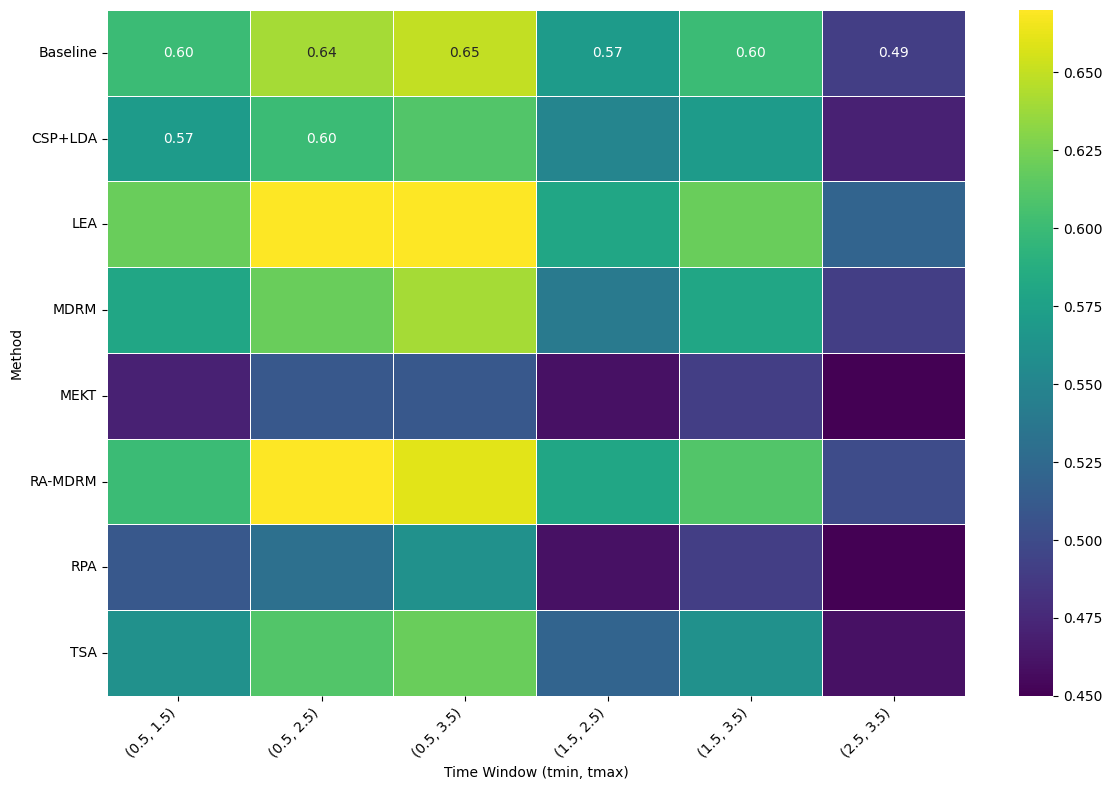

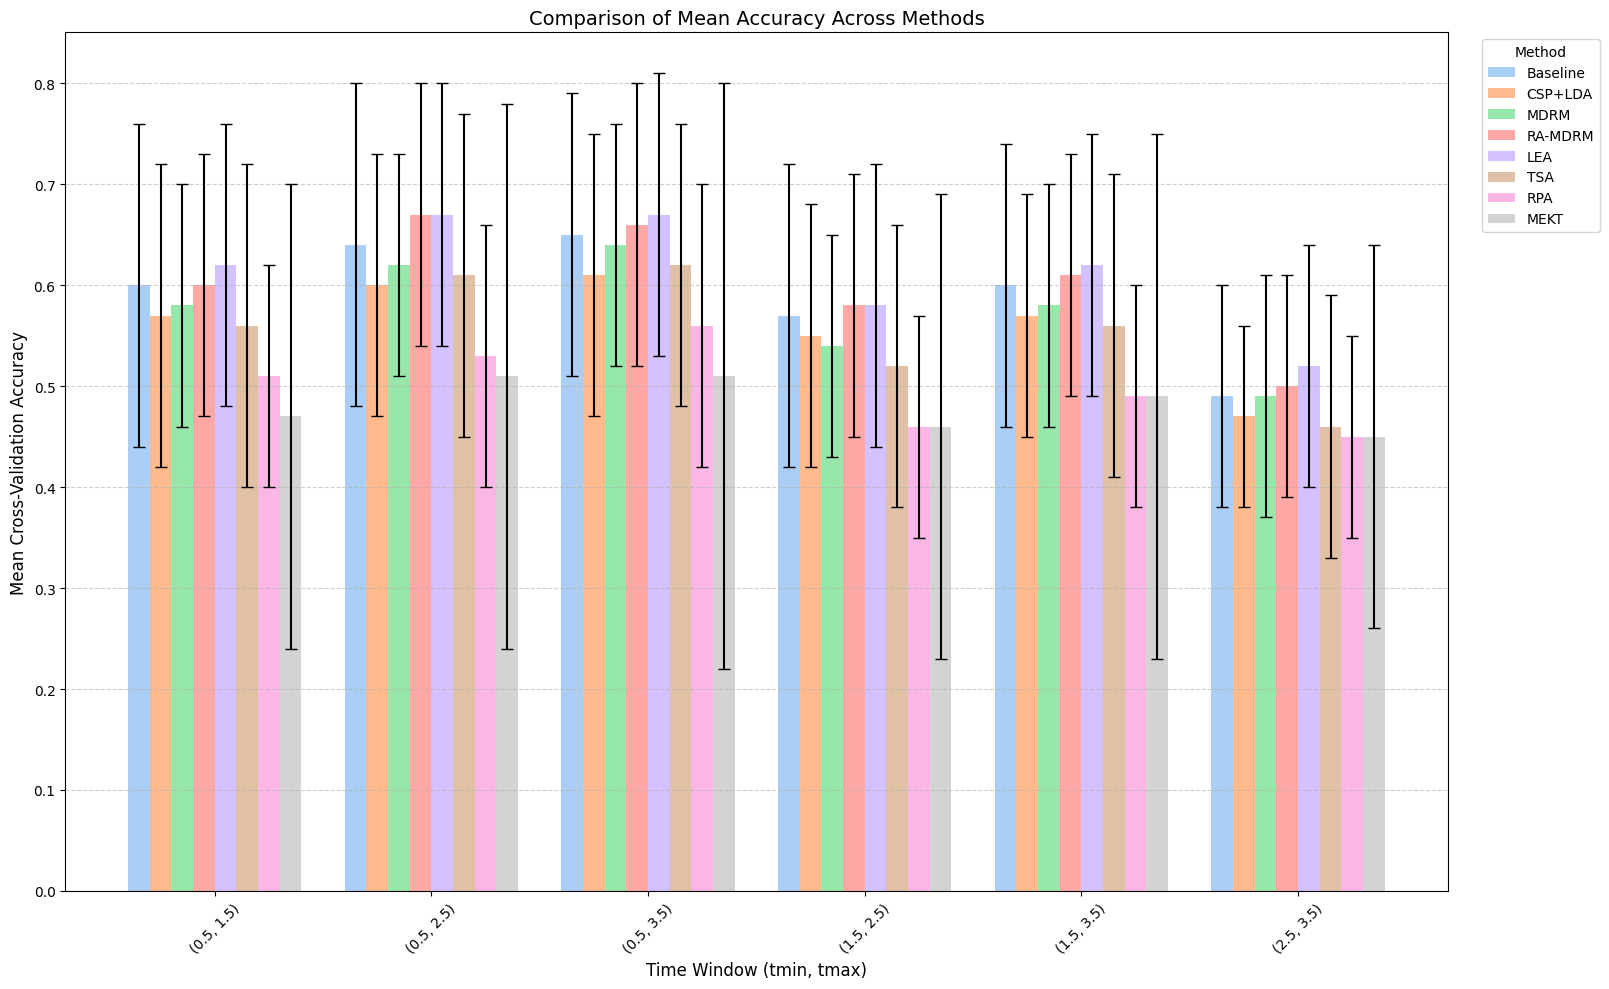

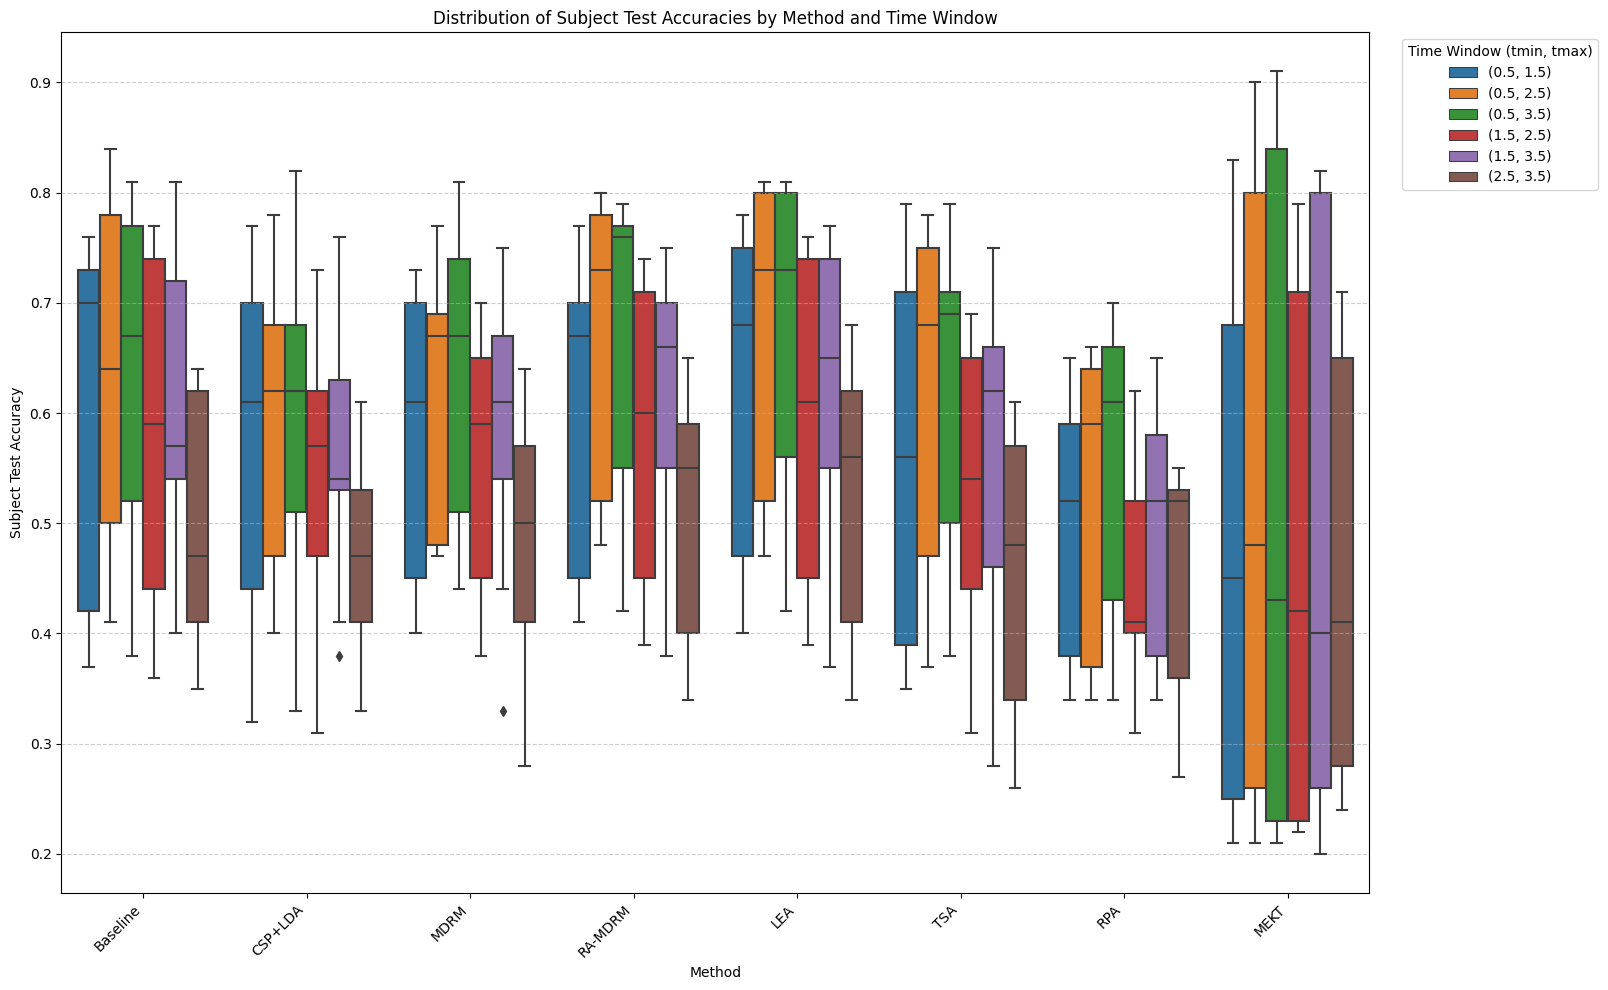

Parsed Mean Accuracy Data:
     Method  tmin  tmax  TimeWindow  MeanAccuracy  StdDev
0  Baseline   0.5   3.5  (0.5, 3.5)          0.65    0.14
1  Baseline   0.5   2.5  (0.5, 2.5)          0.64    0.16
2  Baseline   0.5   1.5  (0.5, 1.5)          0.60    0.16
3  Baseline   1.5   3.5  (1.5, 3.5)          0.60    0.14
4  Baseline   1.5   2.5  (1.5, 2.5)          0.57    0.15

Parsed Subject Accuracy Data:
     Method  tmin  tmax  TimeWindow  Subject  Accuracy
0  Baseline   0.5   3.5  (0.5, 3.5)        1      0.76
1  Baseline   0.5   3.5  (0.5, 3.5)        2      0.52
2  Baseline   0.5   3.5  (0.5, 3.5)        3      0.77
3  Baseline   0.5   3.5  (0.5, 3.5)        4      0.66
4  Baseline   0.5   3.5  (0.5, 3.5)        5      0.38


In [8]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Raw data string provided by the user
data = """
Baseline: 4 class

tmin:  0.5  tmax:  3.5
Subject 1 Test Accuracy: 0.76
Subject 2 Test Accuracy: 0.52
Subject 3 Test Accuracy: 0.77
Subject 4 Test Accuracy: 0.66
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.80
Subject 8 Test Accuracy: 0.81
Subject 9 Test Accuracy: 0.67
Mean Cross-Validation Accuracy: 0.65 ± 0.14

tmin:  0.5  tmax:  2.5
Subject 1 Test Accuracy: 0.79
Subject 2 Test Accuracy: 0.42
Subject 3 Test Accuracy: 0.76
Subject 4 Test Accuracy: 0.61
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.50
Subject 7 Test Accuracy: 0.84
Subject 8 Test Accuracy: 0.78
Subject 9 Test Accuracy: 0.64
Mean Cross-Validation Accuracy: 0.64 ± 0.16

tmin:  0.5  tmax:  1.5
Subject 1 Test Accuracy: 0.70
Subject 2 Test Accuracy: 0.37
Subject 3 Test Accuracy: 0.73
Subject 4 Test Accuracy: 0.52
Subject 5 Test Accuracy: 0.42
Subject 6 Test Accuracy: 0.40
Subject 7 Test Accuracy: 0.73
Subject 8 Test Accuracy: 0.76
Subject 9 Test Accuracy: 0.76
Mean Cross-Validation Accuracy: 0.60 ± 0.16

tmin:  1.5  tmax:  3.5
Subject 1 Test Accuracy: 0.72
Subject 2 Test Accuracy: 0.54
Subject 3 Test Accuracy: 0.81
Subject 4 Test Accuracy: 0.57
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.40
Subject 7 Test Accuracy: 0.75
Subject 8 Test Accuracy: 0.56
Subject 9 Test Accuracy: 0.62
Mean Cross-Validation Accuracy: 0.60 ± 0.14

tmin:  1.5  tmax:  2.5
Subject 1 Test Accuracy: 0.75
Subject 2 Test Accuracy: 0.44
Subject 3 Test Accuracy: 0.77
Subject 4 Test Accuracy: 0.44
Subject 5 Test Accuracy: 0.36
Subject 6 Test Accuracy: 0.40
Subject 7 Test Accuracy: 0.74
Subject 8 Test Accuracy: 0.59
Subject 9 Test Accuracy: 0.62
Mean Cross-Validation Accuracy: 0.57 ± 0.15

tmin:  2.5  tmax:  3.5
Subject 1 Test Accuracy: 0.64
Subject 2 Test Accuracy: 0.45
Subject 3 Test Accuracy: 0.62
Subject 4 Test Accuracy: 0.41
Subject 5 Test Accuracy: 0.35
Subject 6 Test Accuracy: 0.35
Subject 7 Test Accuracy: 0.64
Subject 8 Test Accuracy: 0.47
Subject 9 Test Accuracy: 0.50
Mean Cross-Validation Accuracy: 0.49 ± 0.11


CSP+LDA: 4 class


tmin:  0.5  tmax:  3.5
Subject 1 Test Accuracy: 0.78
Subject 2 Test Accuracy: 0.48
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.62
Subject 5 Test Accuracy: 0.33
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.62
Subject 8 Test Accuracy: 0.82
Subject 9 Test Accuracy: 0.64
Mean Cross-Validation Accuracy: 0.61 ± 0.14

tmin:  0.5  tmax:  2.5
Subject 1 Test Accuracy: 0.78
Subject 2 Test Accuracy: 0.40
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.62
Subject 5 Test Accuracy: 0.40
Subject 6 Test Accuracy: 0.47
Subject 7 Test Accuracy: 0.66
Subject 8 Test Accuracy: 0.76
Subject 9 Test Accuracy: 0.59
Mean Cross-Validation Accuracy: 0.60 ± 0.13


tmin:  0.5  tmax:  1.5
Subject 1 Test Accuracy: 0.72
Subject 2 Test Accuracy: 0.32
Subject 3 Test Accuracy: 0.66
Subject 4 Test Accuracy: 0.53
Subject 5 Test Accuracy: 0.36
Subject 6 Test Accuracy: 0.44
Subject 7 Test Accuracy: 0.61
Subject 8 Test Accuracy: 0.77
Subject 9 Test Accuracy: 0.70
Mean Cross-Validation Accuracy: 0.57 ± 0.15


tmin:  1.5  tmax:  3.5
Subject 1 Test Accuracy: 0.72
Subject 2 Test Accuracy: 0.53
Subject 3 Test Accuracy: 0.76
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.41
Subject 7 Test Accuracy: 0.59
Subject 8 Test Accuracy: 0.54
Subject 9 Test Accuracy: 0.63
Mean Cross-Validation Accuracy: 0.57 ± 0.12

tmin:  1.5  tmax:  2.5
Subject 1 Test Accuracy: 0.73
Subject 2 Test Accuracy: 0.47
Subject 3 Test Accuracy: 0.72
Subject 4 Test Accuracy: 0.50
Subject 5 Test Accuracy: 0.31
Subject 6 Test Accuracy: 0.40
Subject 7 Test Accuracy: 0.57
Subject 8 Test Accuracy: 0.59
Subject 9 Test Accuracy: 0.62
Mean Cross-Validation Accuracy: 0.55 ± 0.13

tmin:  2.5  tmax:  3.5
Subject 1 Test Accuracy: 0.61
Subject 2 Test Accuracy: 0.45
Subject 3 Test Accuracy: 0.58
Subject 4 Test Accuracy: 0.41
Subject 5 Test Accuracy: 0.33
Subject 6 Test Accuracy: 0.34
Subject 7 Test Accuracy: 0.51
Subject 8 Test Accuracy: 0.47
Subject 9 Test Accuracy: 0.53
Mean Cross-Validation Accuracy: 0.47 ± 0.09

MDRM: 4 Class:

tmin:  0.5  tmax:  3.5
Subject 1 Test Accuracy: 0.81
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.70
Subject 4 Test Accuracy: 0.67
Subject 5 Test Accuracy: 0.44
Subject 6 Test Accuracy: 0.49
Subject 7 Test Accuracy: 0.60
Subject 8 Test Accuracy: 0.74
Subject 9 Test Accuracy: 0.76
Mean Cross-Validation Accuracy: 0.64 ± 0.12

tmin:  0.5  tmax:  2.5
Subject 1 Test Accuracy: 0.77
Subject 2 Test Accuracy: 0.48
Subject 3 Test Accuracy: 0.69
Subject 4 Test Accuracy: 0.64
Subject 5 Test Accuracy: 0.48
Subject 6 Test Accuracy: 0.47
Subject 7 Test Accuracy: 0.67
Subject 8 Test Accuracy: 0.69
Subject 9 Test Accuracy: 0.72
Mean Cross-Validation Accuracy: 0.62 ± 0.11

tmin:  0.5  tmax:  1.5
Subject 1 Test Accuracy: 0.67
Subject 2 Test Accuracy: 0.40
Subject 3 Test Accuracy: 0.70
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.45
Subject 6 Test Accuracy: 0.42
Subject 7 Test Accuracy: 0.61
Subject 8 Test Accuracy: 0.73
Subject 9 Test Accuracy: 0.70
Mean Cross-Validation Accuracy: 0.58 ± 0.12

tmin:  1.5  tmax:  3.5
Subject 1 Test Accuracy: 0.75
Subject 2 Test Accuracy: 0.54
Subject 3 Test Accuracy: 0.67
Subject 4 Test Accuracy: 0.61
Subject 5 Test Accuracy: 0.33
Subject 6 Test Accuracy: 0.44
Subject 7 Test Accuracy: 0.55
Subject 8 Test Accuracy: 0.67
Subject 9 Test Accuracy: 0.66
Mean Cross-Validation Accuracy: 0.58 ± 0.12

tmin:  1.5  tmax:  2.5
Subject 1 Test Accuracy: 0.70
Subject 2 Test Accuracy: 0.45
Subject 3 Test Accuracy: 0.65
Subject 4 Test Accuracy: 0.48
Subject 5 Test Accuracy: 0.39
Subject 6 Test Accuracy: 0.38
Subject 7 Test Accuracy: 0.59
Subject 8 Test Accuracy: 0.60
Subject 9 Test Accuracy: 0.66
Mean Cross-Validation Accuracy: 0.54 ± 0.11

tmin:  2.5  tmax:  3.5
Subject 1 Test Accuracy: 0.64
Subject 2 Test Accuracy: 0.45
Subject 3 Test Accuracy: 0.63
Subject 4 Test Accuracy: 0.41
Subject 5 Test Accuracy: 0.28
Subject 6 Test Accuracy: 0.36
Subject 7 Test Accuracy: 0.50
Subject 8 Test Accuracy: 0.57
Subject 9 Test Accuracy: 0.57
Mean Cross-Validation Accuracy: 0.49 ± 0.12

RA-MDRM: 4 class
tmin:  0.5  tmax:  3.5
Subject 1 Test Accuracy: 0.77
Subject 2 Test Accuracy: 0.55
Subject 3 Test Accuracy: 0.79
Subject 4 Test Accuracy: 0.66
Subject 5 Test Accuracy: 0.42
Subject 6 Test Accuracy: 0.48
Subject 7 Test Accuracy: 0.76
Subject 8 Test Accuracy: 0.77
Subject 9 Test Accuracy: 0.76
Mean Cross-Validation Accuracy: 0.66 ± 0.14

tmin:  0.5  tmax:  2.5
Subject 1 Test Accuracy: 0.77
Subject 2 Test Accuracy: 0.52
Subject 3 Test Accuracy: 0.80
Subject 4 Test Accuracy: 0.62
Subject 5 Test Accuracy: 0.48
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.78
Subject 8 Test Accuracy: 0.79
Subject 9 Test Accuracy: 0.73
Mean Cross-Validation Accuracy: 0.67 ± 0.13

tmin:  0.5  tmax:  1.5
Subject 1 Test Accuracy: 0.67
Subject 2 Test Accuracy: 0.41
Subject 3 Test Accuracy: 0.74
Subject 4 Test Accuracy: 0.58
Subject 5 Test Accuracy: 0.45
Subject 6 Test Accuracy: 0.43
Subject 7 Test Accuracy: 0.68
Subject 8 Test Accuracy: 0.77
Subject 9 Test Accuracy: 0.70
Mean Cross-Validation Accuracy: 0.60 ± 0.13

tmin:  1.5  tmax:  3.5
Subject 1 Test Accuracy: 0.70
Subject 2 Test Accuracy: 0.55
Subject 3 Test Accuracy: 0.75
Subject 4 Test Accuracy: 0.59
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.44
Subject 7 Test Accuracy: 0.74
Subject 8 Test Accuracy: 0.69
Subject 9 Test Accuracy: 0.66
Mean Cross-Validation Accuracy: 0.61 ± 0.12

tmin:  1.5  tmax:  2.5
Subject 1 Test Accuracy: 0.72
Subject 2 Test Accuracy: 0.45
Subject 3 Test Accuracy: 0.71
Subject 4 Test Accuracy: 0.50
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.39
Subject 7 Test Accuracy: 0.74
Subject 8 Test Accuracy: 0.60
Subject 9 Test Accuracy: 0.67
Mean Cross-Validation Accuracy: 0.58 ± 0.13

tmin:  2.5  tmax:  3.5
Subject 1 Test Accuracy: 0.59
Subject 2 Test Accuracy: 0.40
Subject 3 Test Accuracy: 0.65
Subject 4 Test Accuracy: 0.43
Subject 5 Test Accuracy: 0.34
Subject 6 Test Accuracy: 0.36
Subject 7 Test Accuracy: 0.64
Subject 8 Test Accuracy: 0.55
Subject 9 Test Accuracy: 0.57
Mean Cross-Validation Accuracy: 0.50 ± 0.11



LEA: 4 class

tmin:  0.5  tmax:  3.5
Subject 1 Test Accuracy: 0.80
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.81
Subject 4 Test Accuracy: 0.64
Subject 5 Test Accuracy: 0.42
Subject 6 Test Accuracy: 0.48
Subject 7 Test Accuracy: 0.77
Subject 8 Test Accuracy: 0.80
Subject 9 Test Accuracy: 0.73
Mean Cross-Validation Accuracy: 0.67 ± 0.14

tmin:  0.5  tmax:  2.5
Subject 1 Test Accuracy: 0.80
Subject 2 Test Accuracy: 0.52
Subject 3 Test Accuracy: 0.81
Subject 4 Test Accuracy: 0.62
Subject 5 Test Accuracy: 0.47
Subject 6 Test Accuracy: 0.52
Subject 7 Test Accuracy: 0.78
Subject 8 Test Accuracy: 0.80
Subject 9 Test Accuracy: 0.73
Mean Cross-Validation Accuracy: 0.67 ± 0.13

tmin:  0.5  tmax:  1.5
Subject 1 Test Accuracy: 0.71
Subject 2 Test Accuracy: 0.40
Subject 3 Test Accuracy: 0.77
Subject 4 Test Accuracy: 0.59
Subject 5 Test Accuracy: 0.47
Subject 6 Test Accuracy: 0.44
Subject 7 Test Accuracy: 0.68
Subject 8 Test Accuracy: 0.78
Subject 9 Test Accuracy: 0.75
Mean Cross-Validation Accuracy: 0.62 ± 0.14

tmin:  1.5  tmax:  3.5
Subject 1 Test Accuracy: 0.74
Subject 2 Test Accuracy: 0.55
Subject 3 Test Accuracy: 0.77
Subject 4 Test Accuracy: 0.57
Subject 5 Test Accuracy: 0.37
Subject 6 Test Accuracy: 0.44
Subject 7 Test Accuracy: 0.76
Subject 8 Test Accuracy: 0.71
Subject 9 Test Accuracy: 0.65
Mean Cross-Validation Accuracy: 0.62 ± 0.13

tmin:  1.5  tmax:  2.5
Subject 1 Test Accuracy: 0.74
Subject 2 Test Accuracy: 0.45
Subject 3 Test Accuracy: 0.76
Subject 4 Test Accuracy: 0.51
Subject 5 Test Accuracy: 0.39
Subject 6 Test Accuracy: 0.40
Subject 7 Test Accuracy: 0.74
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.66
Mean Cross-Validation Accuracy: 0.58 ± 0.14

tmin:  2.5  tmax:  3.5
Subject 1 Test Accuracy: 0.62
Subject 2 Test Accuracy: 0.41
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.45
Subject 5 Test Accuracy: 0.34
Subject 6 Test Accuracy: 0.36
Subject 7 Test Accuracy: 0.66
Subject 8 Test Accuracy: 0.56
Subject 9 Test Accuracy: 0.56
Mean Cross-Validation Accuracy: 0.52 ± 0.12

TSA: 4 class

tmin:  0.5  tmax:  3.5
Subject 1 Test Accuracy: 0.79
Subject 2 Test Accuracy: 0.50
Subject 3 Test Accuracy: 0.78
Subject 4 Test Accuracy: 0.56
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.47
Subject 7 Test Accuracy: 0.71
Subject 8 Test Accuracy: 0.71
Subject 9 Test Accuracy: 0.69
Mean Cross-Validation Accuracy: 0.62 ± 0.14

tmin:  0.5  tmax:  2.5
Subject 1 Test Accuracy: 0.75
Subject 2 Test Accuracy: 0.47
Subject 3 Test Accuracy: 0.78
Subject 4 Test Accuracy: 0.53
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.37
Subject 7 Test Accuracy: 0.68
Subject 8 Test Accuracy: 0.78
Subject 9 Test Accuracy: 0.72
Mean Cross-Validation Accuracy: 0.61 ± 0.16

tmin:  0.5  tmax:  1.5
Subject 1 Test Accuracy: 0.64
Subject 2 Test Accuracy: 0.36
Subject 3 Test Accuracy: 0.71
Subject 4 Test Accuracy: 0.52
Subject 5 Test Accuracy: 0.39
Subject 6 Test Accuracy: 0.35
Subject 7 Test Accuracy: 0.56
Subject 8 Test Accuracy: 0.79
Subject 9 Test Accuracy: 0.72
Mean Cross-Validation Accuracy: 0.56 ± 0.16

tmin:  1.5  tmax:  3.5
Subject 1 Test Accuracy: 0.71
Subject 2 Test Accuracy: 0.46
Subject 3 Test Accuracy: 0.75
Subject 4 Test Accuracy: 0.48
Subject 5 Test Accuracy: 0.28
Subject 6 Test Accuracy: 0.38
Subject 7 Test Accuracy: 0.65
Subject 8 Test Accuracy: 0.62
Subject 9 Test Accuracy: 0.66
Mean Cross-Validation Accuracy: 0.56 ± 0.15

tmin:  1.5  tmax:  2.5
Subject 1 Test Accuracy: 0.67
Subject 2 Test Accuracy: 0.44
Subject 3 Test Accuracy: 0.69
Subject 4 Test Accuracy: 0.47
Subject 5 Test Accuracy: 0.31
Subject 6 Test Accuracy: 0.31
Subject 7 Test Accuracy: 0.63
Subject 8 Test Accuracy: 0.54
Subject 9 Test Accuracy: 0.65
Mean Cross-Validation Accuracy: 0.52 ± 0.14

tmin:  2.5  tmax:  3.5
Subject 1 Test Accuracy: 0.56
Subject 2 Test Accuracy: 0.38
Subject 3 Test Accuracy: 0.60
Subject 4 Test Accuracy: 0.26
Subject 5 Test Accuracy: 0.31
Subject 6 Test Accuracy: 0.34
Subject 7 Test Accuracy: 0.57
Subject 8 Test Accuracy: 0.48
Subject 9 Test Accuracy: 0.61
Mean Cross-Validation Accuracy: 0.46 ± 0.13

RPA: 4 class

tmin:  0.5  tmax:  3.5
Subject 1 Test Accuracy: 0.70
Subject 2 Test Accuracy: 0.34
Subject 3 Test Accuracy: 0.66
Subject 4 Test Accuracy: 0.55
Subject 5 Test Accuracy: 0.43
Subject 6 Test Accuracy: 0.36
Subject 7 Test Accuracy: 0.69
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.66
Mean Cross-Validation Accuracy: 0.56 ± 0.14

tmin:  0.5  tmax:  2.5
Subject 1 Test Accuracy: 0.66
Subject 2 Test Accuracy: 0.37
Subject 3 Test Accuracy: 0.62
Subject 4 Test Accuracy: 0.58
Subject 5 Test Accuracy: 0.34
Subject 6 Test Accuracy: 0.37
Subject 7 Test Accuracy: 0.59
Subject 8 Test Accuracy: 0.64
Subject 9 Test Accuracy: 0.65
Mean Cross-Validation Accuracy: 0.53 ± 0.13

tmin:  0.5  tmax:  1.5
Subject 1 Test Accuracy: 0.59
Subject 2 Test Accuracy: 0.34
Subject 3 Test Accuracy: 0.59
Subject 4 Test Accuracy: 0.49
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.38
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.65
Subject 9 Test Accuracy: 0.64
Mean Cross-Validation Accuracy: 0.51 ± 0.11

tmin:  1.5  tmax:  3.5
Subject 1 Test Accuracy: 0.58
Subject 2 Test Accuracy: 0.34
Subject 3 Test Accuracy: 0.53
Subject 4 Test Accuracy: 0.44
Subject 5 Test Accuracy: 0.37
Subject 6 Test Accuracy: 0.38
Subject 7 Test Accuracy: 0.62
Subject 8 Test Accuracy: 0.52
Subject 9 Test Accuracy: 0.65
Mean Cross-Validation Accuracy: 0.49 ± 0.11

tmin:  1.5  tmax:  2.5
Subject 1 Test Accuracy: 0.62
Subject 2 Test Accuracy: 0.40
Subject 3 Test Accuracy: 0.51
Subject 4 Test Accuracy: 0.41
Subject 5 Test Accuracy: 0.31
Subject 6 Test Accuracy: 0.33
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.41
Subject 9 Test Accuracy: 0.59
Mean Cross-Validation Accuracy: 0.46 ± 0.11

tmin:  2.5  tmax:  3.5
Subject 1 Test Accuracy: 0.52
Subject 2 Test Accuracy: 0.33
Subject 3 Test Accuracy: 0.54
Subject 4 Test Accuracy: 0.40
Subject 5 Test Accuracy: 0.27
Subject 6 Test Accuracy: 0.36
Subject 7 Test Accuracy: 0.55
Subject 8 Test Accuracy: 0.52
Subject 9 Test Accuracy: 0.53
Mean Cross-Validation Accuracy: 0.45 ± 0.10


MEKT: 4 class

tmin:  0.5  tmax:  3.5
Subject 1 Test Accuracy: 0.21
Subject 2 Test Accuracy: 0.67
Subject 3 Test Accuracy: 0.89
Subject 4 Test Accuracy: 0.23
Subject 5 Test Accuracy: 0.43
Subject 6 Test Accuracy: 0.23
Subject 7 Test Accuracy: 0.84
Subject 8 Test Accuracy: 0.91
Subject 9 Test Accuracy: 0.22
Mean Cross-Validation Accuracy: 0.51 ± 0.29

tmin:  0.5  tmax:  2.5
Subject 1 Test Accuracy: 0.24
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.90
Subject 4 Test Accuracy: 0.27
Subject 5 Test Accuracy: 0.48
Subject 6 Test Accuracy: 0.26
Subject 7 Test Accuracy: 0.80
Subject 8 Test Accuracy: 0.87
Subject 9 Test Accuracy: 0.21
Mean Cross-Validation Accuracy: 0.51 ± 0.27

tmin:  0.5  tmax:  1.5
Subject 1 Test Accuracy: 0.24
Subject 2 Test Accuracy: 0.48
Subject 3 Test Accuracy: 0.83
Subject 4 Test Accuracy: 0.21
Subject 5 Test Accuracy: 0.45
Subject 6 Test Accuracy: 0.25
Subject 7 Test Accuracy: 0.68
Subject 8 Test Accuracy: 0.80
Subject 9 Test Accuracy: 0.25
Mean Cross-Validation Accuracy: 0.47 ± 0.23

tmin:  1.5  tmax:  3.5
Subject 1 Test Accuracy: 0.20
Subject 2 Test Accuracy: 0.65
Subject 3 Test Accuracy: 0.82
Subject 4 Test Accuracy: 0.29
Subject 5 Test Accuracy: 0.40
Subject 6 Test Accuracy: 0.26
Subject 7 Test Accuracy: 0.80
Subject 8 Test Accuracy: 0.81
Subject 9 Test Accuracy: 0.20
Mean Cross-Validation Accuracy: 0.49 ± 0.26

tmin:  1.5  tmax:  2.5
Subject 1 Test Accuracy: 0.23
Subject 2 Test Accuracy: 0.53
Subject 3 Test Accuracy: 0.79
Subject 4 Test Accuracy: 0.26
Subject 5 Test Accuracy: 0.42
Subject 6 Test Accuracy: 0.23
Subject 7 Test Accuracy: 0.71
Subject 8 Test Accuracy: 0.76
Subject 9 Test Accuracy: 0.22
Mean Cross-Validation Accuracy: 0.46 ± 0.23

tmin:  2.5  tmax:  3.5
Subject 1 Test Accuracy: 0.24
Subject 2 Test Accuracy: 0.55
Subject 3 Test Accuracy: 0.71
Subject 4 Test Accuracy: 0.28
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.28
Subject 7 Test Accuracy: 0.69
Subject 8 Test Accuracy: 0.65
Subject 9 Test Accuracy: 0.27
Mean Cross-Validation Accuracy: 0.45 ± 0.19
"""

# Regex patterns
method_pattern = re.compile(r"^(.*?):\s*4\s*class", re.IGNORECASE | re.MULTILINE)
time_pattern = re.compile(r"tmin:\s*([\d.]+)\s*tmax:\s*([\d.]+)")
subject_pattern = re.compile(r"Subject\s*(\d+)\s*Test Accuracy:\s*([\d.]+)")
mean_pattern = re.compile(r"Mean Cross-Validation Accuracy:\s*([\d.]+)\s*±\s*([\d.]+)")

# Split data by method
# Find all method headers first
method_headers = method_pattern.findall(data)
# Split the data string based on these headers
split_data = method_pattern.split(data)

# The first part before the first match might be empty or contain the first method's data
# The subsequent parts will be [header1, data1, header2, data2, ...]
if len(split_data) > 1:
    # Check if the first element contains data before the first explicit header
    first_chunk = split_data[0].strip()
    if first_chunk:
        # Assume the first chunk belongs to a default method name if not captured
        # Or handle it based on expected structure (in this case, it seems the first block was unlabeled)
        # Let's manually add "Baseline" as the first method name
        processed_splits = [("Baseline", first_chunk)]
    else:
        processed_splits = []

    # Process the rest of the splits
    for i in range(1, len(split_data), 2):
         # Handle cases where split might not perfectly align if regex matches differently
        if i + 1 < len(split_data):
            method_name = split_data[i].strip()
            method_data = split_data[i+1].strip()
            # Clean up method names that might include extra colons
            method_name = method_name.replace(':', '').strip()
            processed_splits.append((method_name, method_data))
        else:
            # Log or handle potential parsing issues
            print(f"Warning: Skipping potentially misaligned split part: {split_data[i]}")


else:
    # Handle case where no methods were found or data format is unexpected
    print("Warning: Could not split data by method using the provided pattern.")
    processed_splits = []


parsed_data = []
subject_data = []

# Process each method's data block
for method_name, method_data_block in processed_splits:
    # Split the method block into time window segments
    time_segments = time_pattern.split(method_data_block)

    # Start from index 1, as the first element is the text before the first time window
    segment_idx = 1
    while segment_idx < len(time_segments):
        tmin_str = time_segments[segment_idx]
        tmax_str = time_segments[segment_idx + 1]
        segment_data = time_segments[segment_idx + 2]

        try:
            tmin = float(tmin_str)
            tmax = float(tmax_str)
            time_window_label = f"({tmin}, {tmax})"

            # Find mean accuracy and std dev
            mean_match = mean_pattern.search(segment_data)
            if mean_match:
                mean_acc = float(mean_match.group(1))
                std_dev = float(mean_match.group(2))

                # Append the summary data for mean plots
                parsed_data.append({
                    "Method": method_name,
                    "tmin": tmin,
                    "tmax": tmax,
                    "TimeWindow": time_window_label,
                    "MeanAccuracy": mean_acc,
                    "StdDev": std_dev
                })

                # Find individual subject accuracies
                subject_matches = subject_pattern.findall(segment_data)
                for subj_num, subj_acc_str in subject_matches:
                     subject_data.append({
                        "Method": method_name,
                        "tmin": tmin,
                        "tmax": tmax,
                        "TimeWindow": time_window_label,
                        "Subject": int(subj_num),
                        "Accuracy": float(subj_acc_str)
                    })

            else:
                 print(f"Warning: Mean accuracy not found for {method_name} - {time_window_label}")

        except ValueError as e:
            print(f"Warning: Could not parse float values for {method_name} - tmin='{tmin_str}', tmax='{tmax_str}'. Error: {e}")
        except IndexError as e:
             print(f"Warning: Index error while processing segments for {method_name}. Check data structure. Error: {e}")


        segment_idx += 3 # Move to the next tmin value


# Create DataFrames
df_mean = pd.DataFrame(parsed_data)
df_subjects = pd.DataFrame(subject_data)

# Define a consistent order for time windows for plotting
time_window_order = sorted(df_mean['TimeWindow'].unique(), key=lambda x: (float(x[1:].split(',')[0]), float(x[:-1].split(',')[1])))
method_order = df_mean['Method'].unique() # Keep original order or sort if needed

# --- Visualization 1: Heatmap of Mean Accuracies ---
plt.figure(figsize=(12, 8))
heatmap_data = df_mean.pivot(index="Method", columns="TimeWindow", values="MeanAccuracy")
# Reindex columns to ensure consistent order
heatmap_data = heatmap_data[time_window_order]
print("\nNumber of NaN values:", heatmap_data.isnull().sum().sum()) # Count total NaNs
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
# plt.title('Mean Cross-Validation Accuracy by Method and Time Window')
plt.xlabel('Time Window (tmin, tmax)')
plt.ylabel('Method')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# --- Visualization 2: Grouped Bar Chart of Mean Accuracies ---
fig, ax = plt.subplots(figsize=(18, 10))

# Define positions for the bars
n_methods = len(method_order)
n_windows = len(time_window_order)
bar_width = 0.8 / n_methods # Adjust width based on number of methods
index = np.arange(n_windows) # Positions for each group of bars (each time window)

pastel_colors = sns.color_palette("pastel", n_colors=n_methods)

# Create bars for each method
for i, method in enumerate(method_order):
    method_df = df_mean[df_mean['Method'] == method].set_index('TimeWindow').reindex(time_window_order)
    bar_positions = index + i * bar_width
    ax.bar(bar_positions, method_df['MeanAccuracy'], bar_width,
           yerr=method_df['StdDev'], label=method, capsize=4, alpha=0.9, # Slightly increased alpha for pastels
           color=pastel_colors[i % len(pastel_colors)]) # --- Assign color from the palette ---

ax.set_xlabel('Time Window (tmin, tmax)', fontsize=12)
ax.set_ylabel('Mean Cross-Validation Accuracy', fontsize=12)
ax.set_title('Comparison of Mean Accuracy Across Methods', fontsize=14)
ax.set_xticks(index + bar_width * (n_methods - 1) / 2) # Center ticks between grouped bars
ax.set_xticklabels(time_window_order)
ax.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(bottom=0) # Start y-axis at 0
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for legend
plt.show()


# --- Visualization 3: Box Plot of Subject Accuracies ---
plt.figure(figsize=(18, 10))
# Create an interaction term for easier plotting if needed, or use hue
# df_subjects['Method_Window'] = df_subjects['Method'] + '\n' + df_subjects['TimeWindow']
# sns.boxplot(data=df_subjects, x='TimeWindow', y='Accuracy', hue='Method', order=time_window_order) # Group by time window first
sns.boxplot(data=df_subjects, x='Method', y='Accuracy', hue='TimeWindow', order=method_order, hue_order=time_window_order) # Group by method first

plt.title('Distribution of Subject Test Accuracies by Method and Time Window')
plt.xlabel('Method')
plt.ylabel('Subject Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Time Window (tmin, tmax)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout
plt.show()

# Print the first few rows of the dataframes to show parsing results
print("Parsed Mean Accuracy Data:")
print(df_mean.head())
print("\nParsed Subject Accuracy Data:")
print(df_subjects.head())

In [9]:
# Print mean accuracies table
print("\nMean Accuracies Table:")
print(heatmap_data.to_string())


Mean Accuracies Table:
TimeWindow  (0.5, 1.5)  (0.5, 2.5)  (0.5, 3.5)  (1.5, 2.5)  (1.5, 3.5)  (2.5, 3.5)
Method                                                                            
Baseline          0.60        0.64        0.65        0.57        0.60        0.49
CSP+LDA           0.57        0.60        0.61        0.55        0.57        0.47
LEA               0.62        0.67        0.67        0.58        0.62        0.52
MDRM              0.58        0.62        0.64        0.54        0.58        0.49
MEKT              0.47        0.51        0.51        0.46        0.49        0.45
RA-MDRM           0.60        0.67        0.66        0.58        0.61        0.50
RPA               0.51        0.53        0.56        0.46        0.49        0.45
TSA               0.56        0.61        0.62        0.52        0.56        0.46


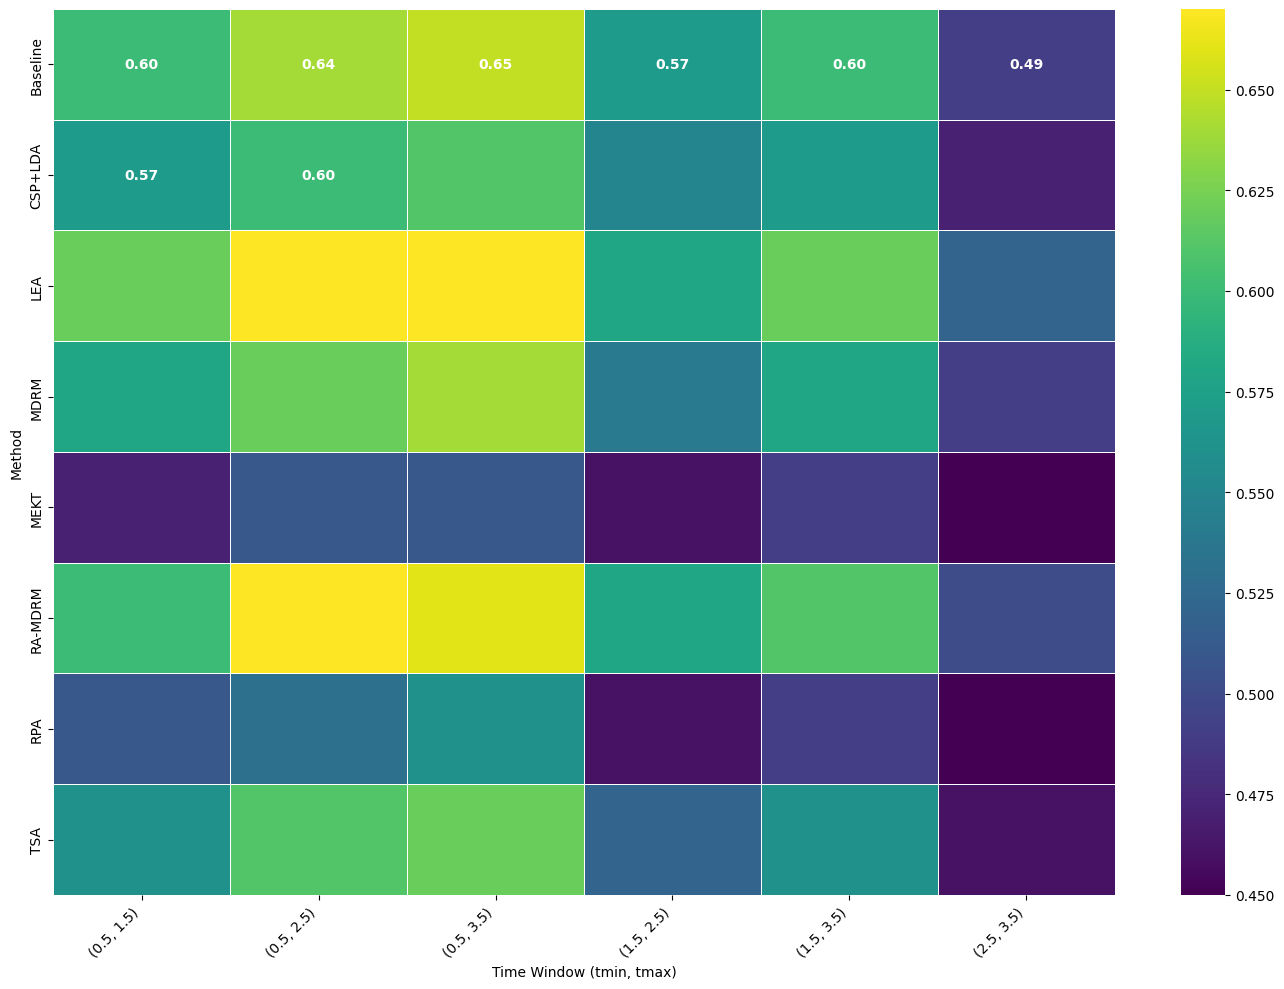

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the data
data = {
    'TimeWindow': ['(0.5, 1.5)', '(0.5, 2.5)', '(0.5, 3.5)', '(1.5, 2.5)', '(1.5, 3.5)', '(2.5, 3.5)'],
    'Baseline': [0.60, 0.64, 0.65, 0.57, 0.60, 0.49],
    'CSP+LDA': [0.57, 0.60, 0.61, 0.55, 0.57, 0.47],
    'LEA': [0.62, 0.67, 0.67, 0.58, 0.62, 0.52],
    'MDRM': [0.58, 0.62, 0.64, 0.54, 0.58, 0.49],
    'MEKT': [0.47, 0.51, 0.51, 0.46, 0.49, 0.45],
    'RA-MDRM': [0.60, 0.67, 0.66, 0.58, 0.61, 0.50],
    'RPA': [0.51, 0.53, 0.56, 0.46, 0.49, 0.45],
    'TSA': [0.56, 0.61, 0.62, 0.52, 0.56, 0.46]
}

# Create DataFrame and transpose it
df = pd.DataFrame(data)
heatmap_data = df.set_index('TimeWindow').T
heatmap_data.index.name = 'Method'

# Set figure size
plt.figure(figsize=(14, 10))

# Create heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=.5,
    annot_kws={"size": 10, "color": "white", "weight": "bold"}
)

# Customize plot
plt.xticks(rotation=45, ha='right')
plt.xlabel('Time Window (tmin, tmax)')
plt.ylabel('Method')
plt.tight_layout()

# Show plot
plt.show()

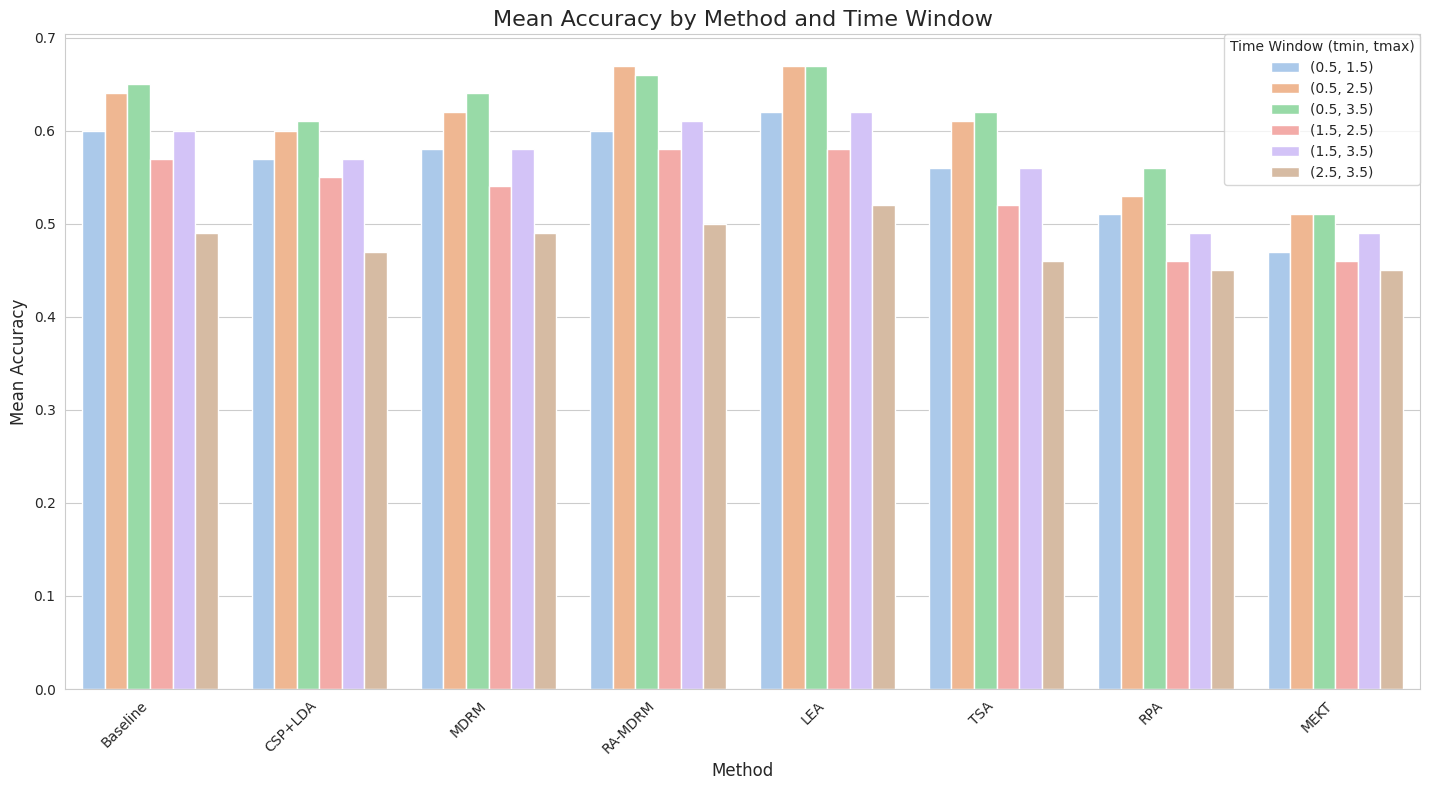


Mean Accuracy DataFrame:
     Method  tmin  tmax  TimeWindow  MeanAccuracy  StdDev
0  Baseline   0.5   3.5  (0.5, 3.5)          0.65    0.14
1  Baseline   0.5   2.5  (0.5, 2.5)          0.64    0.16
2  Baseline   0.5   1.5  (0.5, 1.5)          0.60    0.16
3  Baseline   1.5   3.5  (1.5, 3.5)          0.60    0.14
4  Baseline   1.5   2.5  (1.5, 2.5)          0.57    0.15

Subject Accuracy DataFrame:
     Method  tmin  tmax  TimeWindow  Subject  Accuracy
0  Baseline   0.5   3.5  (0.5, 3.5)        1      0.76
1  Baseline   0.5   3.5  (0.5, 3.5)        2      0.52
2  Baseline   0.5   3.5  (0.5, 3.5)        3      0.77
3  Baseline   0.5   3.5  (0.5, 3.5)        4      0.66
4  Baseline   0.5   3.5  (0.5, 3.5)        5      0.38


In [16]:
# --- Plotting ---
if not df_mean.empty:
    # Define a consistent order for time windows for plotting
    # Sort by tmin first, then tmax
    time_window_order = sorted(df_mean['TimeWindow'].unique(), key=lambda x: (float(x.strip('()').split(',')[0]), float(x.strip('()').split(',')[1])))

    # Get unique methods in the order they appear in the parsed data
    method_order = df_mean['Method'].unique()

    # Set plot style
    sns.set_style("whitegrid")
    plt.figure(figsize=(16, 8)) # Increase figure size for better readability

    # Create the grouped bar plot
    ax = sns.barplot(
        data=df_mean,
        x='Method',
        y='MeanAccuracy',
        hue='TimeWindow',
        order=method_order,       # Specify method order
        hue_order=time_window_order, # Specify time window order
        palette='pastel',         # Use pastel colors
        errorbar='sd'             # Show standard deviation as error bars
        # ci=None # Use this instead of errorbar='sd' if you don't want error bars
    )

    # Add titles and labels
    plt.title('Mean Accuracy by Method and Time Window', fontsize=16)
    plt.xlabel('Method', fontsize=12)
    plt.ylabel('Mean Accuracy', fontsize=12)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)

    # Improve legend
    plt.legend(title='Time Window (tmin, tmax)', loc='upper right', borderaxespad=0.)

    # Adjust layout to prevent labels/legend overlapping
    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust rect to make space for legend

    # Add value labels on top of bars (optional, can be cluttered)
    # for container in ax.containers:
    #    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=3)

    # Show the plot
    plt.show()

else:
    print("DataFrame is empty. Cannot generate plot. Check parsing logic and input data.")

# Display the first few rows of the DataFrames (optional)
print("\nMean Accuracy DataFrame:")
print(df_mean.head())

print("\nSubject Accuracy DataFrame:")
print(df_subjects.head())